In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
from pyproj import Transformer
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px
import branca.colormap as cm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
RAW_FLOATING_PATH = "../raw/floating/pohang_202408.csv"
RAW_RESTAURANT_PATH = "../raw/pohang_휴게음식점_240507.csv"
LSDM_ADM_PATH = "../raw/LSMD_ADM_SECT_UMD_경북/LSMD_ADM_SECT_UMD_47_202603.shp"
RAW_CAFE_PATH = "../raw/소상공인시장진흥공단_개인카페_포항.csv"

FLOATING_SAVE_PATH = "../data/pohang_location_202408.csv"

df_raw_floating = pd.read_csv(RAW_FLOATING_PATH)
df_raw_restaurant = pd.read_csv(RAW_RESTAURANT_PATH)
df_raw_cafe = pd.read_csv(RAW_CAFE_PATH, encoding="utf-8")

### 데이터 전처리1: 위경도 좌표 변환

In [3]:
# 좌표 변환 (UTM-K -> 위경도)
transformer = Transformer.from_crs("epsg:5179", "epsg:4326", always_xy=True)
lons, lats = transformer.transform(df_raw_floating['xcnts'].values, df_raw_floating['ydnts'].values)
df_raw_floating['lat'] = lats
df_raw_floating['lon'] = lons

### 데이터 전처리2: SSH 파일로 위경도와 읍면동 컬럼 매칭 후 추가

In [4]:
# SHP 파일 로드
pohang_map = gpd.read_file(LSDM_ADM_PATH, encoding='cp949')

# 유동인구를 지리 데이터로 변환
gdf_points = gpd.GeoDataFrame(
    df_raw_floating,
    geometry=gpd.points_from_xy(df_raw_floating['lon'], df_raw_floating['lat']),
    crs="EPSG:4326"
)

# 공간 결합
pohang_map = pohang_map.to_crs("EPSG:4326")
df_floating = gpd.sjoin(gdf_points, pohang_map, how='left', predicate='within') # 'EMD_NM'은 읍면동 컬럼

### 데이터 전처리3: nan 제거 및 읍면동 컬럼을 기준으로 행정동 컬럼 추가

In [5]:
# 포항시(남구 47111, 북구 47113) 데이터만 필터링 및 NaN 제거
df_floating = df_floating[df_floating['EMD_CD'].astype(str).str.startswith(('47111', '47113'))].copy()
df_floating = df_floating.dropna(subset=['EMD_NM'])

def map_to_admin_dong(row):
    legal_dong = row['EMD_NM']

    # 읍면동 -> 행정동 매칭
    mapping = {
        '중앙동': ['동빈1가', '동빈2가', '남빈동', '상원동', '신흥동', '대흥동', '덕산동', '덕수동', '여천동', '중앙동', '항구동', '학산동', '대신동'],
        '양학동': ['득량동', '학잠동'],
        '우창동': ['우현동', '창포동'],
        '용흥동': ['용흥동'],
        '환여동': ['환호동', '여남동'],
        '두호동': ['두호동'],
        '장량동': ['장성동', '양덕동'],
        '상대동': ['상도동', '대도동'],
        '제철동': ['송내동', '일월동', '인덕동', '호동', '괴동동', '동촌동', '장흥동'],
        '효곡동': ['효자동', '지곡동'],
        '대이동': ['대잠동', '이동'],
        '해도동': ['해도동'],
        '죽도동': ['죽도동'],
        '송도동': ['송도동'],
        '청림동': ['송정동', '청림동'],
        '기북면': ['기북면'],
        '기계면': ['기계면'],
        '장기면': ['장기면'],
        '송라면': ['송라면'],
        '호미곶면': ['호미곶면'],
        '구룡포읍': ['구룡포읍'],
        '청하면': ['청하면'],
        '흥해읍': ['흥해읍'],
        '죽장면': ['죽장면'],
        '신광면': ['신광면'],
        '오천읍': ['오천읍'],
        '연일읍': ['연일읍'],
        '대송면': ['대송면'],
        '동해면': ['동해면']
    }

    for admin_dong, legal_dongs in mapping.items():
        if legal_dong in legal_dongs:
            return admin_dong
    return legal_dong  # 매핑되지 않은 경우 원래 이름 유지

# 'ADMIN_DONG' 컬럼 추가
df_floating['ADMIN_DONG'] = df_floating.apply(map_to_admin_dong, axis=1)

# 결과 저장
df_floating.to_csv(FLOATING_SAVE_PATH, index=False, encoding='utf-8-sig')

print("작업이 완료되었습니다. 이제 동네별로 통계를 낼 수 있습니다!")
print("전처리 완료! 현재 동네 개수 (행정동 기준): %d개" % df_floating['ADMIN_DONG'].nunique())

작업이 완료되었습니다. 이제 동네별로 통계를 낼 수 있습니다!
전처리 완료! 현재 동네 개수 (행정동 기준): 29개


In [20]:
import pandas as pd
import numpy as np

# 1. 데이터 로드
df_danger = pd.read_csv("../raw/단기폐업 위험도.csv", encoding="utf-8")

def map_to_admin_dong(row):
    if '동이름' not in row:
        return np.nan
    
    legal_dong = row['동이름']

    # 행정동 매칭이 필요한 "법정동"들만 남기고 나머지는 삭제했습니다.
    # 여기에 없는 이름(예: 송라면, 기계면 등)이 들어오면 아래에서 np.nan을 반환합니다.
    mapping = {
        '중앙동': ['동빈1가', '동빈2가', '남빈동', '상원동', '신흥동', '대흥동', '덕산동', '덕수동', '여천동', '중앙동', '항구동', '학산동', '대신동'],
        '양학동': ['득량동', '학잠동'],
        '우창동': ['우현동', '창포동'],
        '용흥동': ['용흥동'],
        '환여동': ['환호동', '여남동'],
        '두호동': ['두호동'],
        '장량동': ['장성동', '양덕동'],
        '상대동': ['상도동', '대도동'],
        '제철동': ['송내동', '일월동', '인덕동', '호동', '괴동동', '동촌동', '장흥동'],
        '효곡동': ['효자동', '지곡동'],
        '대이동': ['대잠동', '이동'],
        '해도동': ['해도동'],
        '죽도동': ['죽도동'],
        '송도동': ['송도동'],
        '청림동': ['송정동', '청림동'],
        '기북면': ['기북면'],
        '기계면': ['기계면'],
        '장기면': ['장기면'],
        '송라면': ['송라면'],
        '호미곶면': ['호미곶면'],
        '구룡포읍': ['구룡포읍'],
        '청하면': ['청하면'],
        '흥해읍': ['흥해읍'],
        '죽장면': ['죽장면'],
        '신광면': ['신광면'],
        '오천읍': ['오천읍'],
        '연일읍': ['연일읍'],
        '대송면': ['대송면'],
        '동해면': ['동해면']
    }

    for admin_dong, legal_dongs in mapping.items():
        if legal_dong in legal_dongs:
            return admin_dong
            
    # 매핑 테이블에 없는 경우(송라면 등) 빈 값 반환
    return np.nan

# 2. 'ADMIN_DONG' 컬럼 추가
df_danger.columns = df_danger.columns.str.strip()
df_danger['ADMIN_DONG'] = df_danger.apply(map_to_admin_dong, axis=1)

# 3. 결과 확인
# 제대로 비워졌는지 상위 10개만 출력해서 확인해보세요
print(df_danger[['동이름', 'ADMIN_DONG']].head(10))

# 저장
df_danger.to_csv('../raw/단기폐업 위험도 행정동별.csv', encoding='utf-8-sig', index=False)

   동이름 ADMIN_DONG
0  송라면        송라면
1  송도동        송도동
2  동해면        동해면
3  기계면        기계면
4   이동        대이동
5  대도동        상대동
6  학잠동        양학동
7  효자동        효곡동
8  대송면        대송면
9  해도동        해도동


### 행정동별 구분이 제대로 되었는지 직접 확인하기 위해서 출력

In [7]:
# 라벨링이 완료된 최종 CSV 파일을 불러옵니다.
df_test = pd.read_csv(FLOATING_SAVE_PATH) 

# 지도 생성 (포항 중심)
m = folium.Map(location=[36.019, 129.343], zoom_start=12, tiles=None)

# 구글 지도 배경 레이어
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}',
    attr='Google',
    name='Google Map',
    overlay=False,
    control=True
).add_to(m)

# 3. 'ADMIN_DONG' 컬럼을 기준으로 색상 맵핑 (KeyError 해결!)
unique_dongs = df_test['ADMIN_DONG'].dropna().unique()
# 색상 리스트를 31개 이상으로 확장 (folium에서 지원하는 색상 이름들)
colors = [
    'red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 'beige', 
    'darkblue', 'darkgreen', 'cadetblue', 'pink', 'lightblue', 'lightgreen', 
    'gray', 'black', 'darkpurple', 'lightgray', 'blue', 'green', 'red', 
    'lightblue', 'lightgreen', 'orange', 'darkred', 'pink', 'cadetblue',
    'darkblue', 'darkgreen', 'purple', 'beige'
]
# 만약 색상 이름이 부족하면 hex 코드를 써도 되지만, folium CircleMarker는 이름이 안전합니다.
dong_color_map = {dong: colors[i % len(colors)] for i, dong in enumerate(unique_dongs)}

# 4. 좌표 찍기 (데이터가 많으므로 상위 5000개만 먼저 확인하거나, 전체를 찍으려면 radius를 작게!)
print("동별로 색상을 입히는 중입니다...")
for _, row in df_test.dropna(subset=['lat', 'lon', 'ADMIN_DONG']).iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=1.5,
        color=dong_color_map[row['ADMIN_DONG']],
        fill=True,
        fill_color=dong_color_map[row['ADMIN_DONG']],
        fill_opacity=0.7,
        weight=0,
        tooltip=f"동네: {row['ADMIN_DONG']} / 인구: {int(row['co'])}명"
    ).add_to(m)

# 5. 결과 확인
m.save('pohang_check_map.html')
print("작성 완료! pohang_check_map.html 파일을 열어보세요.")

동별로 색상을 입히는 중입니다...
작성 완료! pohang_check_map.html 파일을 열어보세요.


In [8]:
# 색상 매핑 결과 출력하기
print("--- [동네별 지도 표시 색상 안내] ---")
for dong, color in dong_color_map.items():
    print(f" {dong.ljust(10)} : {color}")

# 추가로, 동네별로 데이터가 몇 개씩 매칭됐는지도 같이 확인하면 분석할 때 편해요!
print("\n--- [동네별 데이터 포인트 개수] ---")
print(df_test['ADMIN_DONG'].value_counts())

--- [동네별 지도 표시 색상 안내] ---
 죽장면        : red
 기계면        : blue
 기북면        : green
 동해면        : purple
 흥해읍        : orange
 오천읍        : darkred
 중앙동        : lightred
 우창동        : beige
 장량동        : darkblue
 청하면        : darkgreen
 제철동        : cadetblue
 상대동        : pink
 해도동        : lightblue
 죽도동        : lightgreen
 대송면        : gray
 신광면        : black
 송라면        : darkpurple
 연일읍        : lightgray
 장기면        : blue
 효곡동        : green
 구룡포읍       : red
 두호동        : lightblue
 호미곶면       : lightgreen
 송도동        : orange
 대이동        : darkred
 청림동        : pink
 양학동        : cadetblue
 용흥동        : darkblue
 환여동        : darkgreen

--- [동네별 데이터 포인트 개수] ---
ADMIN_DONG
흥해읍     3313
오천읍     2719
장량동     1800
연일읍     1680
효곡동     1235
상대동      877
대이동      847
동해면      812
용흥동      715
우창동      702
죽도동      648
중앙동      611
구룡포읍     600
해도동      570
송도동      504
두호동      451
환여동      431
제철동      385
양학동      361
청림동      286
대송면      211
기계면      204
청하면      166
장기면     

### 배경지도1 유동인구 직사각형으로 표시

### 배경 지도1

In [9]:
m = folium.Map(location=[36.019, 129.343], zoom_start=14, tiles='cartodbpositron')

### 배경 지도2

In [10]:
# m = folium.Map(location=[36.019, 129.343], zoom_start=14, tiles=None)

# folium.TileLayer(
#     tiles = 'https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}',
#     attr = 'Google',
#     name = '구글 지도 (도로)',
#     overlay = False,
#     control = True
# ).add_to(m)

### 배경지도 유동인구

In [11]:
# 컬러맵: 연주황 -> 주황 -> 빨강 -> 진한 빨강
# 인구가 적은 곳은 연한 색, 많은 곳은 진한 색으로 이어지게
colormap = cm.LinearColormap(
    colors=['#FFD580', '#FF8C00', '#E31A1C', '#800026'], # 연주황 -> 주황 -> 빨강 -> 진한빨강
    index=[df_floating['co'].min(), 
           df_floating['co'].quantile(0.5), 
           df_floating['co'].quantile(0.85), 
           df_floating['co'].max()],
    vmin=df_floating['co'].min(),
    vmax=df_floating['co'].max()
)

# 격자 크기
delta = 0.00025 

for _, row in df_floating.iterrows():
    lat, lon = row['lat'], row['lon']
    population = row['co']
    
    # 색상 결정
    color = colormap(population)
    
    # [핵심] 인구수에 비례하여 투명도 조절 (0.1 ~ 0.8 사이)
    # 인구가 적으면 거의 안 보이게(0.1), 많으면 진하게(0.8)
    opacity = 0.2 + (population / df_floating['co'].max()) * 0.7

    rect_bounds = [
        [lat - delta, lon - delta], 
        [lat + delta, lon + delta]
    ]
    
    folium.Rectangle(
        bounds=rect_bounds,
        color=color,
        weight=0.1,             # 테두리는 아주 가늘게 해서 겹쳐 보이지 않게 함
        fill=True,
        fill_color=color,
        fill_opacity=opacity,   # 동적 투명도 적용
        tooltip=f"인구: {int(population)}명"
    ).add_to(m)

# 지도에 컬러바(범례) 추가
colormap.add_to(m)
colormap.caption = 'Floating Population Density'

m.save('pohang_grid_map1.html')
print("--- 그리드 맵 저장 완료! ---")

--- 그리드 맵 저장 완료! ---


### 배경지도 유동인구 + 카페 위치 표시

In [12]:
# 2. 좌표 변환기 설정
# 유동인구: EPSG:5179 -> EPSG:4326(위경도)
trans_floating = Transformer.from_crs("epsg:5179", "epsg:4326", always_xy=True)
# 카페(휴게음식점): EPSG:5174 -> EPSG:4326(위경도)
trans_cafe = Transformer.from_crs("epsg:5174", "epsg:4326", always_xy=True)

# 3. 유동인구 좌표 변환 및 필터링 (기존 로직)
lons, lats = trans_floating.transform(df_floating['xcnts'].values, df_floating['ydnts'].values)
df_floating['lat'], df_floating['lon'] = lats, lons
cutoff = df_floating['co'].quantile(0.75)
df_final = df_floating[df_floating['co'] > cutoff].copy()

# 4. 카페 데이터 필터링 (영업/정상 & 결측치 제거)
df_cafe = df_raw_restaurant[df_raw_restaurant['영업상태명'] == '영업/정상'].copy()
df_cafe = df_cafe.dropna(subset=['좌표정보x(epsg5174)', '좌표정보y(epsg5174)'])

# 카페 좌표 변환
c_lons, c_lats = trans_cafe.transform(df_cafe['좌표정보x(epsg5174)'].values, df_cafe['좌표정보y(epsg5174)'].values)
df_cafe['lat'], df_cafe['lon'] = c_lats, c_lons

# 5. 지도 생성 (배경은 깔끔한 cartodbpositron)
m = folium.Map(location=[36.019, 129.343], zoom_start=14, tiles='cartodbpositron')

# 6. 유동인구 격자 그리기
def get_color(co):
    if co >= df_final['co'].quantile(0.9): return '#800026' # 최상위
    elif co >= df_final['co'].quantile(0.7): return '#e31a1c'
    elif co >= df_final['co'].quantile(0.5): return '#fd8d3c'
    else: return '#fed976'

delta = 0.00025 
for _, row in df_final.iterrows():
    folium.Rectangle(
        bounds=[[row['lat'] - delta, row['lon'] - delta], [row['lat'] + delta, row['lon'] + delta]],
        color=get_color(row['co']),
        weight=0.5,
        fill=True,
        fill_color=get_color(row['co']),
        fill_opacity=0.5,
        tooltip=f"인구: {int(row['co'])}명"
    ).add_to(m)

# 7. 카페 위치 Plot (파란색 작은 점)
for _, row in df_cafe.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=2,               # 카페 위치를 아주 작은 점으로 표시 (2500개라 작아야 잘 보임)
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.7,
        weight=0,
        tooltip=row['사업장명']
    ).add_to(m)

# 8. 저장
m.save('pohang_cafe_analysis.html')
print("--- 분석 지도 생성 완료! 영업 중인 카페 %d개 ---" % len(df_cafe))

--- 분석 지도 생성 완료! 영업 중인 카페 2448개 ---


<Figure size 1600x800 with 0 Axes>

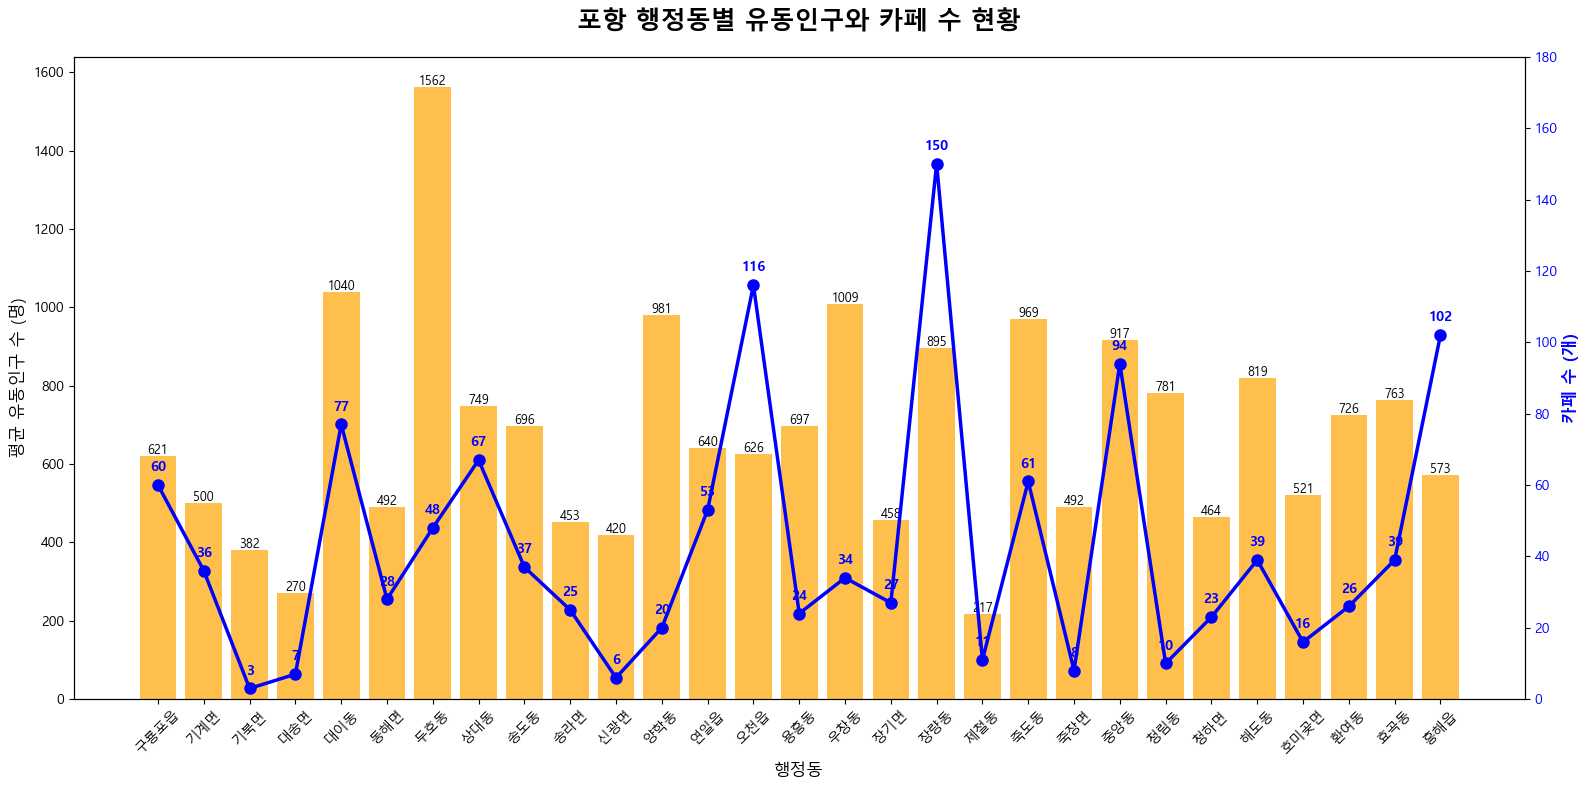

In [13]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(16, 8))

df_floating_avg = df_floating.groupby('ADMIN_DONG')['co'].mean().reset_index()
df_cafe_count = df_raw_cafe.groupby('행정동명').size().reset_index(name='카페수')

df_combined = pd.merge(
    df_floating_avg,
    df_cafe_count,
    left_on='ADMIN_DONG',
    right_on='행정동명',
    how='left'
).fillna(0)
df_combined = df_combined.sort_values('ADMIN_DONG').reset_index(drop=True)

# 2. 그래프 설정
fig, ax1 = plt.subplots(figsize=(16, 8))
plt.rcParams['font.family'] = 'Malgun Gothic'

# x축 위치 설정
x = range(len(df_combined))

colors = plt.cm.viridis(df_combined['co'] / df_combined['co'].max())
ax1.bar(x, df_combined['co'], color='orange', alpha=0.7)

ax1.set_title('포항 행정동별 유동인구와 카페 수 현황', fontsize=18, pad=20, fontweight='bold')
ax1.set_xlabel('행정동', fontsize=12)
ax1.set_ylabel('평균 유동인구 수 (명)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(df_combined['ADMIN_DONG'], rotation=45)

# --- 꺾은선 그래프: 카페 수 ---
ax2 = ax1.twinx()
ax2.plot(x, df_combined['카페수'], color='blue', marker='o', markersize=8, linewidth=2.5)

ax2.set_ylabel('카페 수 (개)', fontsize=12, color='blue', fontweight='bold', fontfamily='Malgun Gothic')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.grid(False)
ax2.set_ylim(0, df_combined['카페수'].max() * 1.2)

# 데이터 라벨링
for i, row in df_combined.iterrows():
    ax1.text(i, row['co'] + 5, f"{row['co']:.0f}", ha='center', fontsize=9, color='black')
    ax2.text(i, row['카페수'] + 3, f"{int(row['카페수'])}", 
             ha='center', va='bottom', fontsize=10, color='blue', fontweight='bold')

plt.tight_layout()
plt.savefig("포항_행정동별_유동인구_카페수_통합.png")
plt.show()

In [14]:
# 필요한 열만 추출 (ADMIN_DONG, co, 카페수)
df_final = df_combined[['ADMIN_DONG', 'co', '카페수']]

# 컬럼명 보기 좋게 변경
df_final.columns = ['행정동', '평균 유동인구수', '카페수']

# CSV 파일로 저장 (인코딩은 엑셀에서 바로 열기 편하도록 'cp949' 권장)
df_final.to_csv("포항_행정동별_상권데이터.csv", index=False, encoding='cp949')

print("CSV 파일 저장 완료!")

CSV 파일 저장 완료!
